In [12]:
import torch

if torch.cuda.is_available():
    print(f"CUDA is available! Found {torch.cuda.device_count()} GPU(s).")
else:
    print("CUDA is not available. PyTorch will use the CPU.")

CUDA is not available. PyTorch will use the CPU.


In [13]:
%env CUDA_VISIBLE_DEVICES=""

env: CUDA_VISIBLE_DEVICES=""


### Calculation of the clustering metrics

The following clustering evaluation metrics were calculated:

- Silhouette score: Measures how well samples fit within their assigned cluster versus the nearest other cluster; ranges [-1, 1], higher is better (1 = well-separated, 0 = overlapping, negative = likely misassigned). (In this case I had true labels so I evaluated it by adding them)
- ARI (Adjusted Rand Index): Compares clustering to ground-truth labels, adjusted for chance; ranges [-1, 1], with 1 = perfect match, 0 ≈ random, negative = worse than random.
- NMI (Normalized Mutual Information): Information-theoretic similarity between clustering and labels; ranges [0, 1], with 1 = identical, 0 = no shared information; robust to differing numbers of clusters.


The Silhouette score was computed twice:
1. Batch (in this case, the “tech” variable)
2. Cell type

These two Silhouette scores were then combined into a single aggregated score:
- When the Batch Silhouette score is close to 0, it is given more importance because this indicates low separation between batches, which is best, it means the method is effectively removing batch effects.
- When the Cell type Silhouette score is close to 1, it is given more importance because this indicates high separation between cell types, which is best, it means biological signals are preserved.

After combining, the aggregated Silhouette score was normalized to the range 0–1.

Finally, the aggregated Silhouette score, ARI, and NMI were combined into a single ranking metric for comparing models.

This procedure was performed first on the whole latent space and then on the UMAP representation derived from that space, to evaluate performance both before and after dimensionality reduction.

---

#### Function definition

In [14]:
import os
import sys
import anndata
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from scvi.model import SCVI
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import torch
import pandas as pd
import scib.metrics
import random
SEED = 55
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

# The notebook is in a subdirectory, so we need to add the parent directory to the path
notebook_path = os.getcwd()
parent_path = os.path.abspath(os.path.join(notebook_path, '..'))
sys.path.append(parent_path)

from federated_scvi_flower.app.utils.model_utils_scvi import get_scvi_model, setup_scvi_anndata
from federated_scvi_flower.app.utils.data_utils_scvi import load_partitioned_anndata, ensure_hvg_genes, load_batch_list, load_hvg_list

def compute_latent_space(model: SCVI, adata_train: anndata.AnnData, adata_test: anndata.AnnData):
    """
    Computes the latent representation for both training and testing AnnData objects.
    """
    print("Computing latent representations...")
    latent_train = model.get_latent_representation()
    latent_test = model.get_latent_representation(adata_test)
    return latent_train, latent_test

def run_downstream_analysis(adata_combined: anndata.AnnData, use_rep: str = "X_scVI"):
    """
    Performs standard downstream analysis: computes neighbors, finds clusters with Leiden, and computes UMAP.
    """
    print("Computing neighbors and UMAP...")
    sc.pp.neighbors(adata_combined, use_rep=use_rep)
    sc.tl.leiden(adata_combined, flavor="igraph", n_iterations=2)
    sc.tl.umap(adata_combined)

def evaluate_scvi_models(
    adata: anndata.AnnData, 
    space: str = "latent", 
    label_key: str = "leiden"
):
    """
    Evaluates the scVI model performance either in the latent space (X_scVI) or in the UMAP space (X_umap).
    
    If space='umap' and X_umap is missing, it will compute the UMAP using X_scVI first.
    """
    if space not in ["latent", "umap"]:
        raise ValueError("space must be either 'latent' or 'umap'")
    
    # Determine the representation key
    if space == "latent":
        use_rep = "X_scVI"
    else:
        use_rep = "X_umap"
        if "X_umap" not in adata.obsm:
            print("UMAP not found. Computing UMAP from X_scVI...")
            run_downstream_analysis(adata, use_rep="X_scVI")  # ensures UMAP exists
    
    latent_data = adata.obsm[use_rep]
    evaluation_results = {}
    
    # Composite Silhouette Score
    celltype_labels = adata.obs.get("celltype", None)
    batch_labels = adata.obs.get("batch", None)

    if celltype_labels is not None and batch_labels is not None:
        if len(np.unique(celltype_labels)) > 1 and len(np.unique(batch_labels)) > 1:
            celltype_score = silhouette_score(latent_data, celltype_labels)
            batch_score = silhouette_score(latent_data, batch_labels)
            norm_celltype = (celltype_score + 1) / 2
            norm_batch = 1 - np.abs(batch_score)
            composite_score = (norm_celltype + norm_batch) / 2
            evaluation_results["composite_silhouette"] = composite_score
            evaluation_results["celltype_silhouette"] = celltype_score
            evaluation_results["batch_silhouette"] = batch_score
        else:
            print("Not enough unique labels for silhouette scores.")
            evaluation_results["composite_silhouette"] = np.nan
            evaluation_results["celltype_silhouette"] = np.nan
            evaluation_results["batch_silhouette"] = np.nan
    else:
        print("Missing 'celltype' or 'batch' in adata.obs.")
        evaluation_results["composite_silhouette"] = np.nan
        evaluation_results["celltype_silhouette"] = np.nan
        evaluation_results["batch_silhouette"] = np.nan

    # ARI & NMI
    if label_key in adata.obs and "celltype" in adata.obs:
        clusters = adata.obs[label_key]
        known_labels = adata.obs["celltype"]
        if len(np.unique(clusters)) > 1 and len(np.unique(known_labels)) > 1:
            evaluation_results["ari"] = adjusted_rand_score(known_labels, clusters)
            evaluation_results["nmi"] = normalized_mutual_info_score(known_labels, clusters)
        else:
            print("Not enough unique labels for ARI/NMI scores.")
            evaluation_results["ari"] = np.nan
            evaluation_results["nmi"] = np.nan
    else:
        print(f"Required labels ('{label_key}' or 'celltype') not found for ARI/NMI.")
        evaluation_results["ari"] = np.nan
        evaluation_results["nmi"] = np.nan
    if all(metric in evaluation_results for metric in [
        "ari", "nmi", "celltype_silhouette", "batch_silhouette"
    ]):
        norm_ari = evaluation_results["ari"]  # Already between 0 and 1
        norm_nmi = evaluation_results["nmi"]  # Already between 0 and 1

        composite_score_extended = (
            norm_celltype + norm_batch + norm_ari + norm_nmi
        ) / 4

        evaluation_results["composite_extended"] = composite_score_extended

    print(f"\n--- Evaluation Results in {space.upper()} space ---")
    for k, v in evaluation_results.items():
        print(f"{k}: {v:.4f}" if not np.isnan(v) else f"{k}: NaN")
    print("----------------------------------------------\n")
    
    return evaluation_results

def run_analysis_pipeline(
    adata_train: anndata.AnnData,
    adata_test: anndata.AnnData,
    model_weights_path: str,
    data_combined: bool,
    space:str = 'latent',
    model_name: str = None,
):
    """
    Main function to run the full analysis pipeline for a given model.
    It returns a dictionary of evaluation scores and the processed AnnData object.
    """
    
    # Load model and set as trained
    if model_name:
        model = get_scvi_model(adata_train, hvg_list)
        print(f"Loading model weights from: {model_name}")
        state_dict = torch.load(model_name)
        if hasattr(model, "module"):
            model.module.load_state_dict(state_dict, strict=True)
        else:
            model.load_state_dict(state_dict, strict=True)
    else:
        model = SCVI.load(model_weights_path, adata_train)

    model.is_trained = True
    
    # Compute latent space and assign to AnnData objects
    latent_train, latent_test = compute_latent_space(model, adata_train, adata_test)
    adata_train.obsm["X_scVI"] = latent_train
    adata_test.obsm["X_scVI"] = latent_test
    
    # Prepare the combined or single dataset for downstream analysis
    if data_combined:
        adata_combined = anndata.concat(
            [adata_train, adata_test],
            label="dataset",
            keys=["train", "test"],
            join="inner",
            index_unique=None,
        )
        adata_combined.obsm["X_scVI"] = np.vstack([latent_train, latent_test])
    else:
        # This is where the test-only data is handled. A copy is used to prevent modifying the original adata_test object.
        adata_combined = adata_test.copy()
        adata_combined.obsm["X_scVI"] = latent_test

    # Run clustering and evaluation
    run_downstream_analysis(adata_combined, use_rep="X_scVI")
    scores = evaluate_scvi_models(adata_combined, space=space, label_key="leiden")

    return scores, adata_combined


def load_and_preprocess_data(data_path: str, hvg_list: list, all_batches: list):
    """
    Loads an AnnData object, preprocesses it for SCVI, and sets up batch information.
    """
    print(f"Loading and preprocessing data from {data_path}...")
    adata = anndata.read_h5ad(data_path)
    adata.obs["batch"] = adata.obs.get("batch", adata.obs.get("tech", "batch0"))
    adata = ensure_hvg_genes(adata, hvg_list)
    setup_scvi_anndata(adata, all_batches=all_batches)
    return adata


def plot_umap_on_ax(ax, adata_obj, title_prefix, color_by_label):
    """
    Helper function to plot UMAPs on a given matplotlib axis with a correct title.
    """
    sc.pl.umap(adata_obj, color=color_by_label, ax=ax, show=False)
    ax.set_title(title_prefix, fontsize=12, fontweight='bold')
    ax.set_xlabel(f"UMAP1 ({color_by_label})")
    ax.set_ylabel(f"UMAP2 ({color_by_label})")

# --- 1. Load and preprocess data only once ---
save_dir = "../models"
hvg_list = load_hvg_list("../0_data/hvg_list.json")
all_batches = load_batch_list("../0_data/batch_list.json")

adata_train = load_and_preprocess_data("../0_data/pancreas_train.h5ad", hvg_list, all_batches)
adata_test = load_and_preprocess_data("../0_data/pancreas_test.h5ad", hvg_list, all_batches)
name_prefix = "3_clients_20_rounds_5_epochs"

Loading and preprocessing data from ../0_data/pancreas_train.h5ad...
Loading and preprocessing data from ../0_data/pancreas_test.h5ad...


In [15]:
def run_full_pipeline(space):
    # --- Initialize dictionaries to store results and AnnData objects for plotting ---
    results_combined = {}
    adata_combined_plots = {}
    results_test = {}
    adata_test_plots = {}

    color_by = "celltype"

    # --- Define configurations for different analyses ---
    analysis_configs = {
        "centralised": {
            "model_weights_path": os.path.join(save_dir, "centralised_model"),
        },
        "federated": {
            "model_weights_path": os.path.join('..', "federated_scvi_flower/app/models", name_prefix),
            "model_name": os.path.join('..', "federated_scvi_flower/app/models", name_prefix, "model.pt"),
        },
    }

    # --- Execute all analyses ---
    for config_name, config in analysis_configs.items():
        print(f"\n--- Running analysis for model: {config_name}_combined ---")
        scores, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            data_combined=True,
            space=space,
            **config
        )
        if scores is not None:
            results_combined[config_name] = scores
        if adata_obj is not None:
            adata_combined_plots[config_name] = adata_obj

        print(f"\n--- Running analysis for model: {config_name}_test ---")
        scores, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            data_combined=False,
            space=space,
            **config
        )
        if scores is not None:
            results_test[config_name] = scores
        if adata_obj is not None:
            adata_test_plots[config_name] = adata_obj

    # --- Handle independent clients ---
    num_clients = 3
    for id_client in range(num_clients):
        client_name = f"independent_client_{id_client}"
        model_path = os.path.join(save_dir, f"independent_client_{id_client}")

        print(f"\n--- Running analysis for model: {client_name}_combined (Modified) ---")
        scores, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            model_weights_path=model_path,
            space=space,
            data_combined=True
        )
        if scores is not None:
            results_combined[client_name] = scores
        if adata_obj is not None:
            adata_combined_plots[client_name] = adata_obj

        print(f"\n--- Running analysis for model: {client_name}_test ---")
        scores, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            model_weights_path=model_path,
            space=space,
            data_combined=False
        )
        if scores is not None:
            results_test[client_name] = scores
        if adata_obj is not None:
            adata_test_plots[client_name] = adata_obj

    print("\n--- Analysis pipeline completed successfully! ---")
    print("\n--- Generating Final Report ---")

    plot_labels = list(adata_combined_plots.keys())
    num_plots = len(plot_labels)

    # === Global font size ===
    SMALL_SIZE = 9
    MEDIUM_SIZE = 11
    BIGGER_SIZE = 13
    plt.rc('font', size=SMALL_SIZE)
    plt.rc('axes', titlesize=MEDIUM_SIZE)
    plt.rc('axes', labelsize=MEDIUM_SIZE)
    plt.rc('xtick', labelsize=SMALL_SIZE)
    plt.rc('ytick', labelsize=SMALL_SIZE)
    plt.rc('legend', fontsize=SMALL_SIZE)
    plt.rc('figure', titlesize=BIGGER_SIZE)

    # === Figure 1: UMAPs ===
    fig_umap, axes = plt.subplots(num_plots, 2, figsize=(18, 6 * num_plots))
    fig_umap.suptitle(f"SCVI Analysis Report ({space} space)", fontsize=BIGGER_SIZE, fontweight='bold')
    axes[0, 0].set_title("Combined (Train + Test) UMAPs", fontsize=MEDIUM_SIZE, fontweight='bold')
    axes[0, 1].set_title("Test Only UMAPs", fontsize=MEDIUM_SIZE, fontweight='bold')

    for i, title in enumerate(plot_labels):
        if title in adata_combined_plots:
            plot_umap_on_ax(axes[i, 0], adata_combined_plots[title], f"{title} (Combined)", color_by)
        if title in adata_test_plots:
            plot_umap_on_ax(axes[i, 1], adata_test_plots[title], f"{title} (Test)", color_by)

    fig_umap.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()

    # === Figure 2: Composite Silhouette Scores ===
    all_results_composite = {
        **{f"{k} (train + test)": v["composite_silhouette"] for k, v in results_combined.items()},
        **{f"{k} (test)": v["composite_silhouette"] for k, v in results_test.items()}
    }
    fig_sil, ax_sil = plt.subplots(figsize=(10, 6))
    pd.Series(all_results_composite).sort_values().plot(
        kind='bar', ax=ax_sil, color=['skyblue'] * len(all_results_composite)
    )
    ax_sil.set_title(f"Silhouette Scores `[Cell_type_score + (1-|Batch_score|)] / 2` ({space} space)", fontsize=MEDIUM_SIZE, fontweight='bold')
    ax_sil.set_ylabel("Composite Silhouette Score")
    ax_sil.set_xlabel("Model Configuration")
    ax_sil.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # === Figure 3: Composite Extended Scores ===
    all_results_composite_extended = {
        **{f"{k} (train + test)": v["composite_extended"] for k, v in results_combined.items()},
        **{f"{k} (test)": v["composite_extended"] for k, v in results_test.items()}
    }
    fig_ext, ax_ext = plt.subplots(figsize=(10, 6))
    pd.Series(all_results_composite_extended).sort_values().plot(
        kind='bar', ax=ax_ext, color=['orange'] * len(all_results_composite_extended)
    )
    ax_ext.set_title(f"Composite Silhouette + ARI + NMI Scores ({space} space)", fontsize=MEDIUM_SIZE, fontweight='bold')
    ax_ext.set_ylabel("Composite Extended Score")
    ax_ext.set_xlabel("Model Configuration")
    ax_ext.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # === Final results table ===
    print("\n\n--- Final Summary of All Evaluation Metrics ---")
    combined_df = pd.DataFrame(results_combined).T
    test_df = pd.DataFrame(results_test).T
    combined_df.columns = [f"Entire_dataset_{col}" for col in combined_df.columns]
    test_df.columns = [f"Test_{col}" for col in test_df.columns]
    final_df = pd.concat([combined_df, test_df], axis=1)
    display(final_df)
    return final_df

### Metrics evaluated on the latent space


=== Running pipeline in LATENT space ===

--- Running analysis for model: centralised_combined ---
INFO     File ../models/centralised_model/model.pt already downloaded                                              


Computing latent representations...
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Computing neighbors and UMAP...

--- Evaluation Results in LATENT space ---
composite_silhouette: 0.8014
celltype_silhouette: 0.3194
batch_silhouette: -0.0569
ari: 0.4522
nmi: 0.7463
composite_extended: 0.7003
----------------------------------------------


--- Running analysis for model: centralised_test ---
INFO     File ../models/centralised_model/model.pt already downloaded                                              
Computing latent representations...
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Computing neighbors and UMAP...

--- Evaluation Results in LATENT space ---
composite_silhouette: 0.8388
celltype_silhouette: 0.4129
batch_silhouette: 0.0288
ari: 0.5524
nmi: 0.7996
composite_extended: 0.7574
----------------------------------------------


--- Runnin

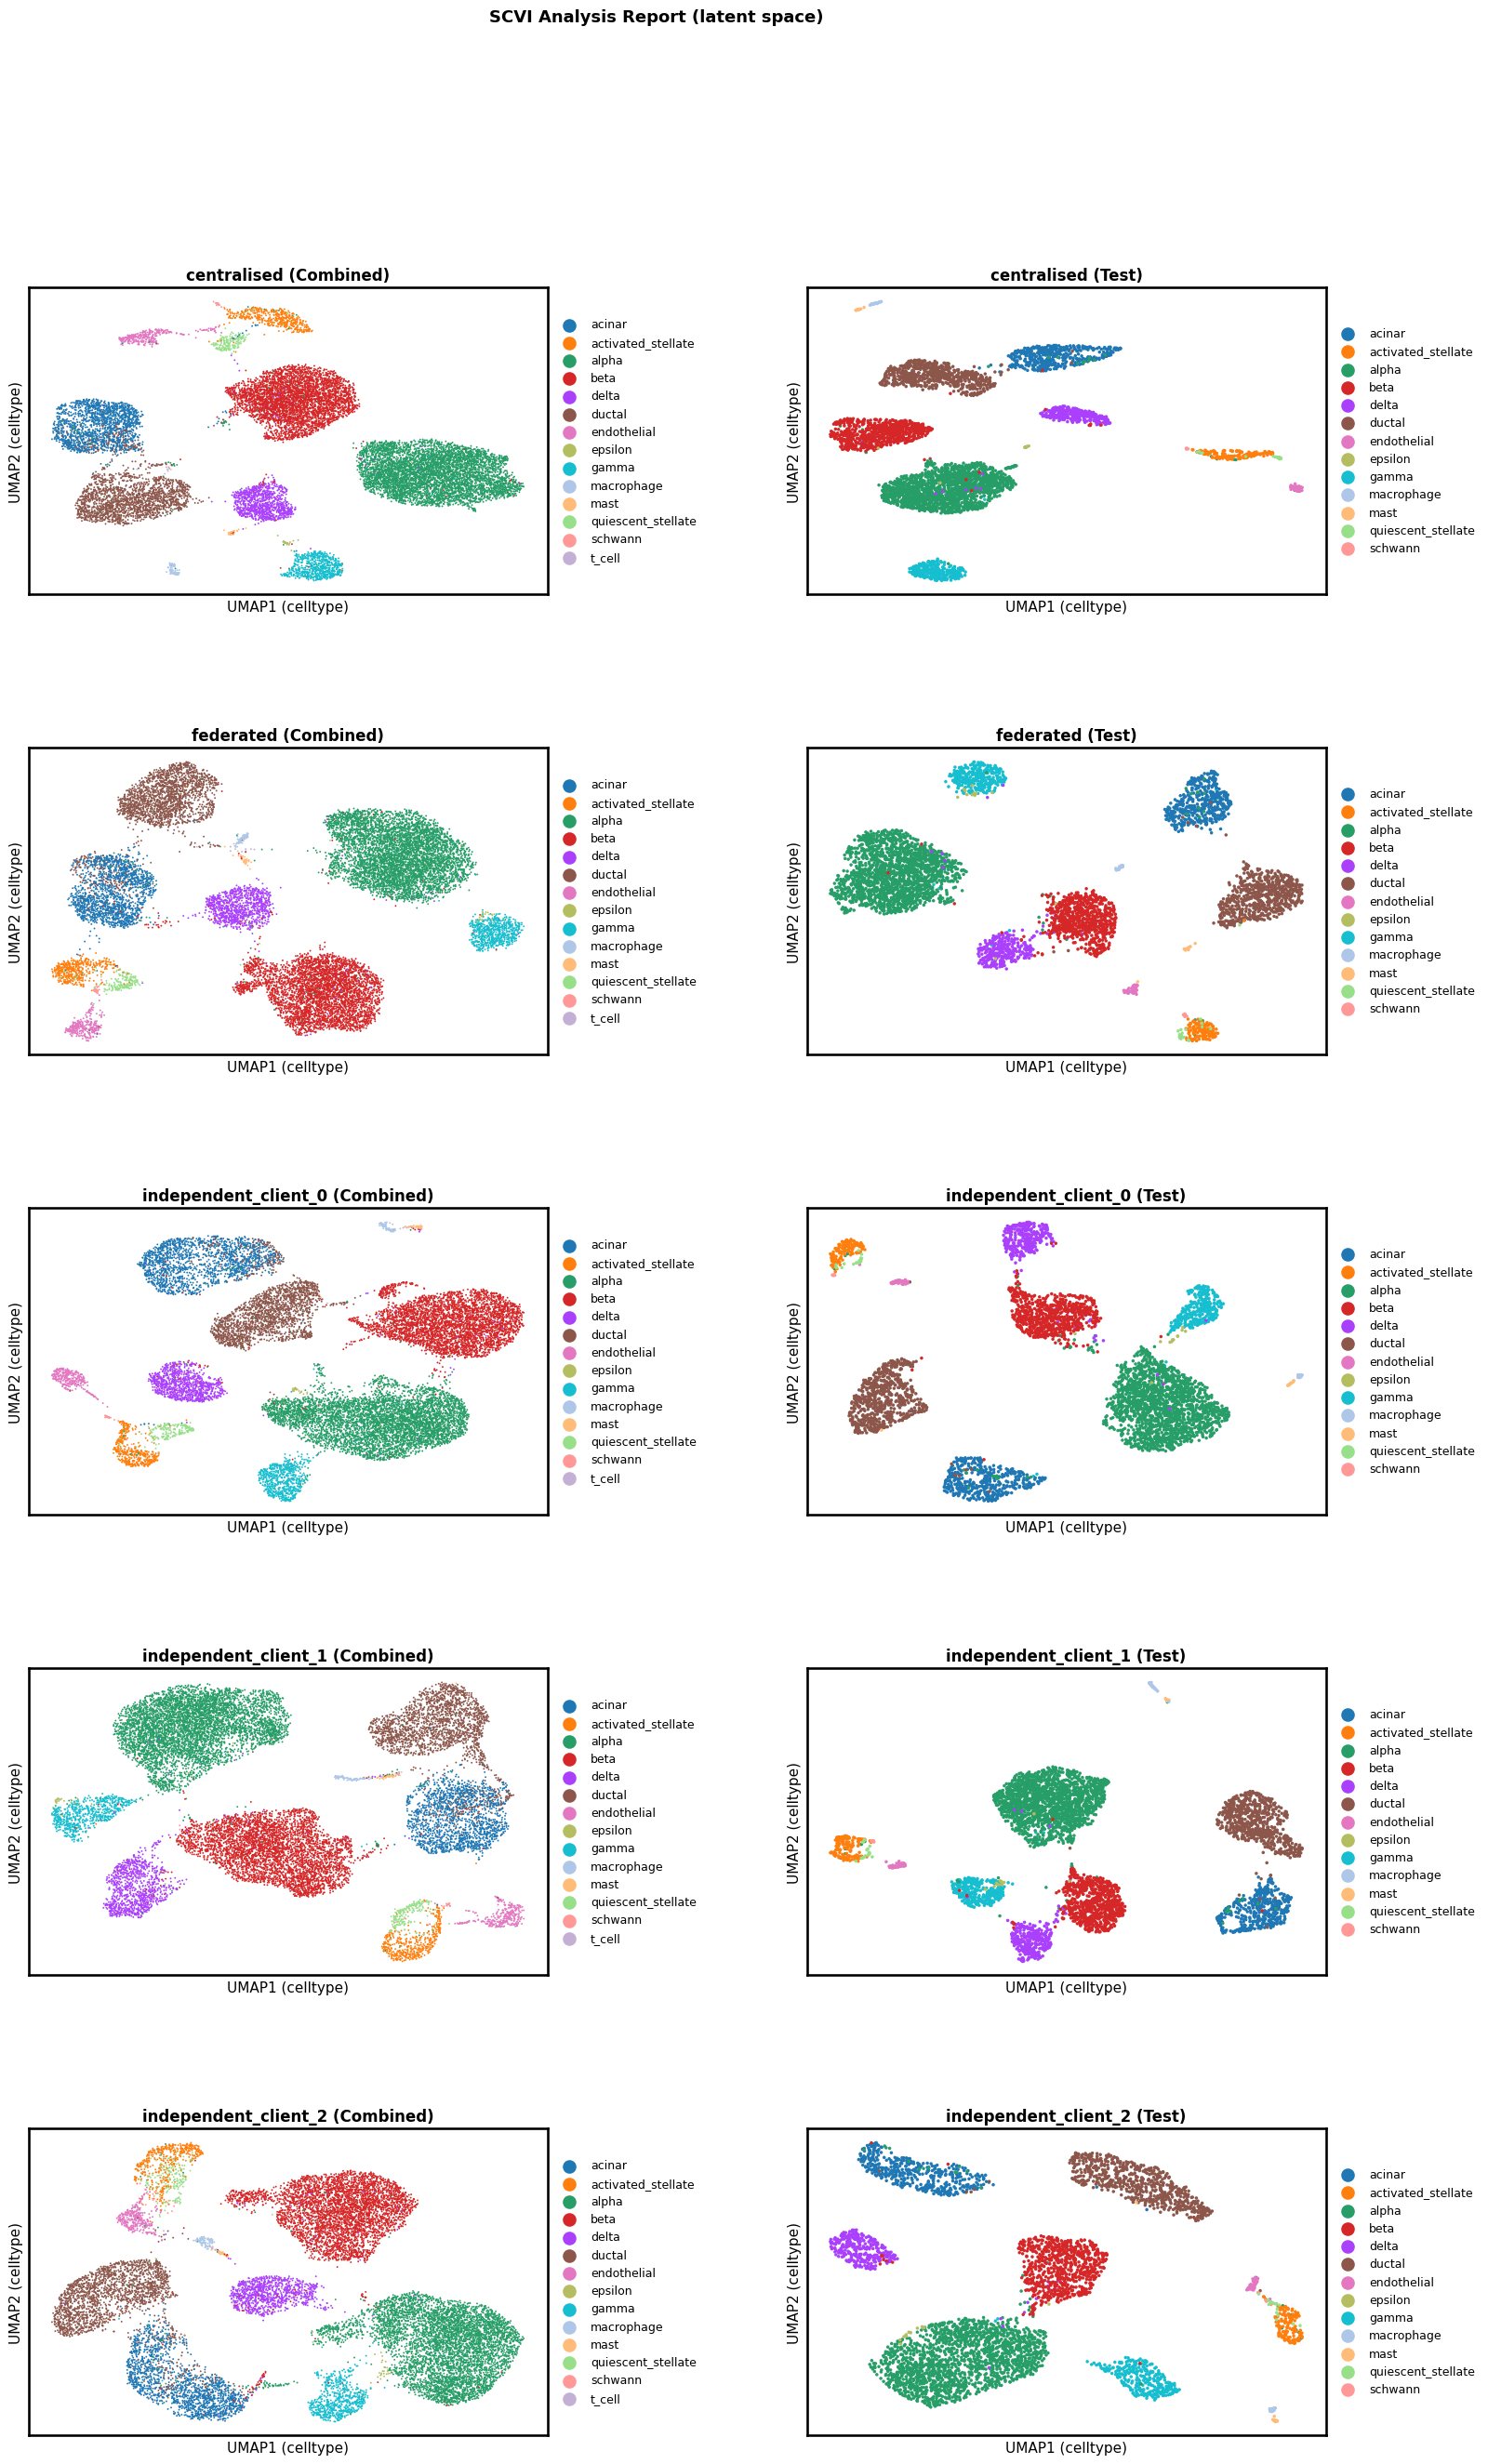

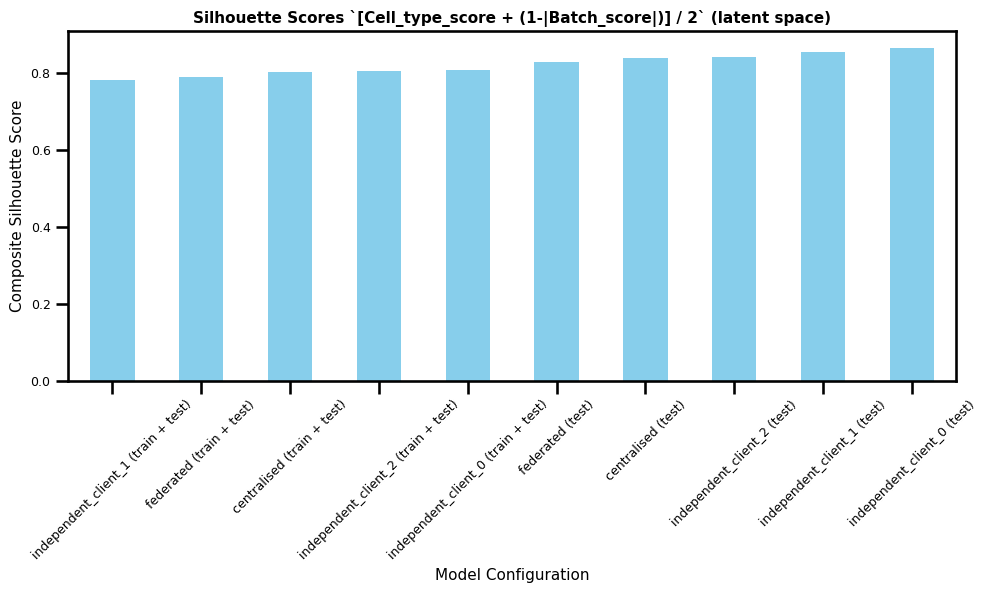

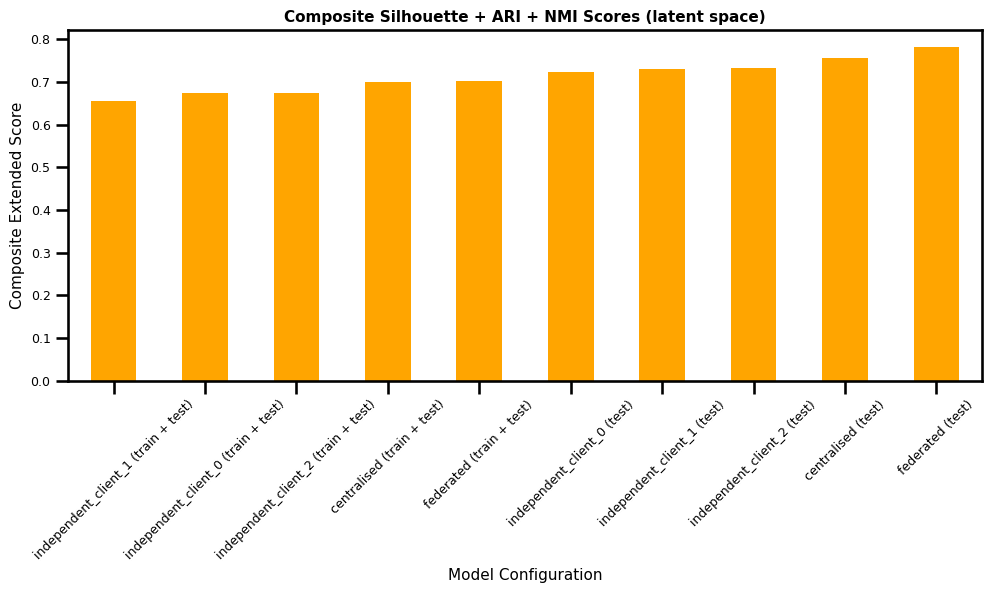



--- Final Summary of All Evaluation Metrics ---


,Entire_dataset_composite_silhouette,Entire_dataset_celltype_silhouette,Entire_dataset_batch_silhouette,Entire_dataset_ari,Entire_dataset_nmi,Entire_dataset_composite_extended,Test_composite_silhouette,Test_celltype_silhouette,Test_batch_silhouette,Test_ari,Test_nmi,Test_composite_extended
centralised,0.801399,0.319423,-0.056914,0.452202,0.746301,0.700325,0.838805,0.412863,0.028821,0.552405,0.799592,0.757402
federated,0.790635,0.287734,-0.062598,0.475178,0.754925,0.702843,0.828070,0.373575,0.030647,0.638193,0.835156,0.782373
independent_client_0,0.808709,0.402474,-0.083819,0.366323,0.711350,0.673773,0.865079,0.506047,0.022865,0.417093,0.747809,0.723765
independent_client_1,0.782524,0.337233,-0.103568,0.361262,0.701341,0.656913,0.854492,0.475667,0.028849,0.446566,0.764172,0.729931
independent_client_2,0.804605,0.337798,-0.059688,0.381438,0.707190,0.674460,0.842171,0.457641,0.044479,0.481680,0.770639,0.734165


In [16]:
print("\n=== Running pipeline in LATENT space ===")
latent_df = run_full_pipeline(space="latent")

### Metrics evaluated on the umap space


=== Running pipeline in UMAP space ===

--- Running analysis for model: centralised_combined ---
INFO     File ../models/centralised_model/model.pt already downloaded                                              
Computing latent representations...
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Computing neighbors and UMAP...

--- Evaluation Results in UMAP space ---
composite_silhouette: 0.7861
celltype_silhouette: 0.4879
batch_silhouette: -0.1718
ari: 0.4522
nmi: 0.7463
composite_extended: 0.6927
----------------------------------------------


--- Running analysis for model: centralised_test ---
INFO     File ../models/centralised_model/model.pt already downloaded                                              
Computing latent representations...
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Computing neighbors and UMAP...

--- Evaluation Results 

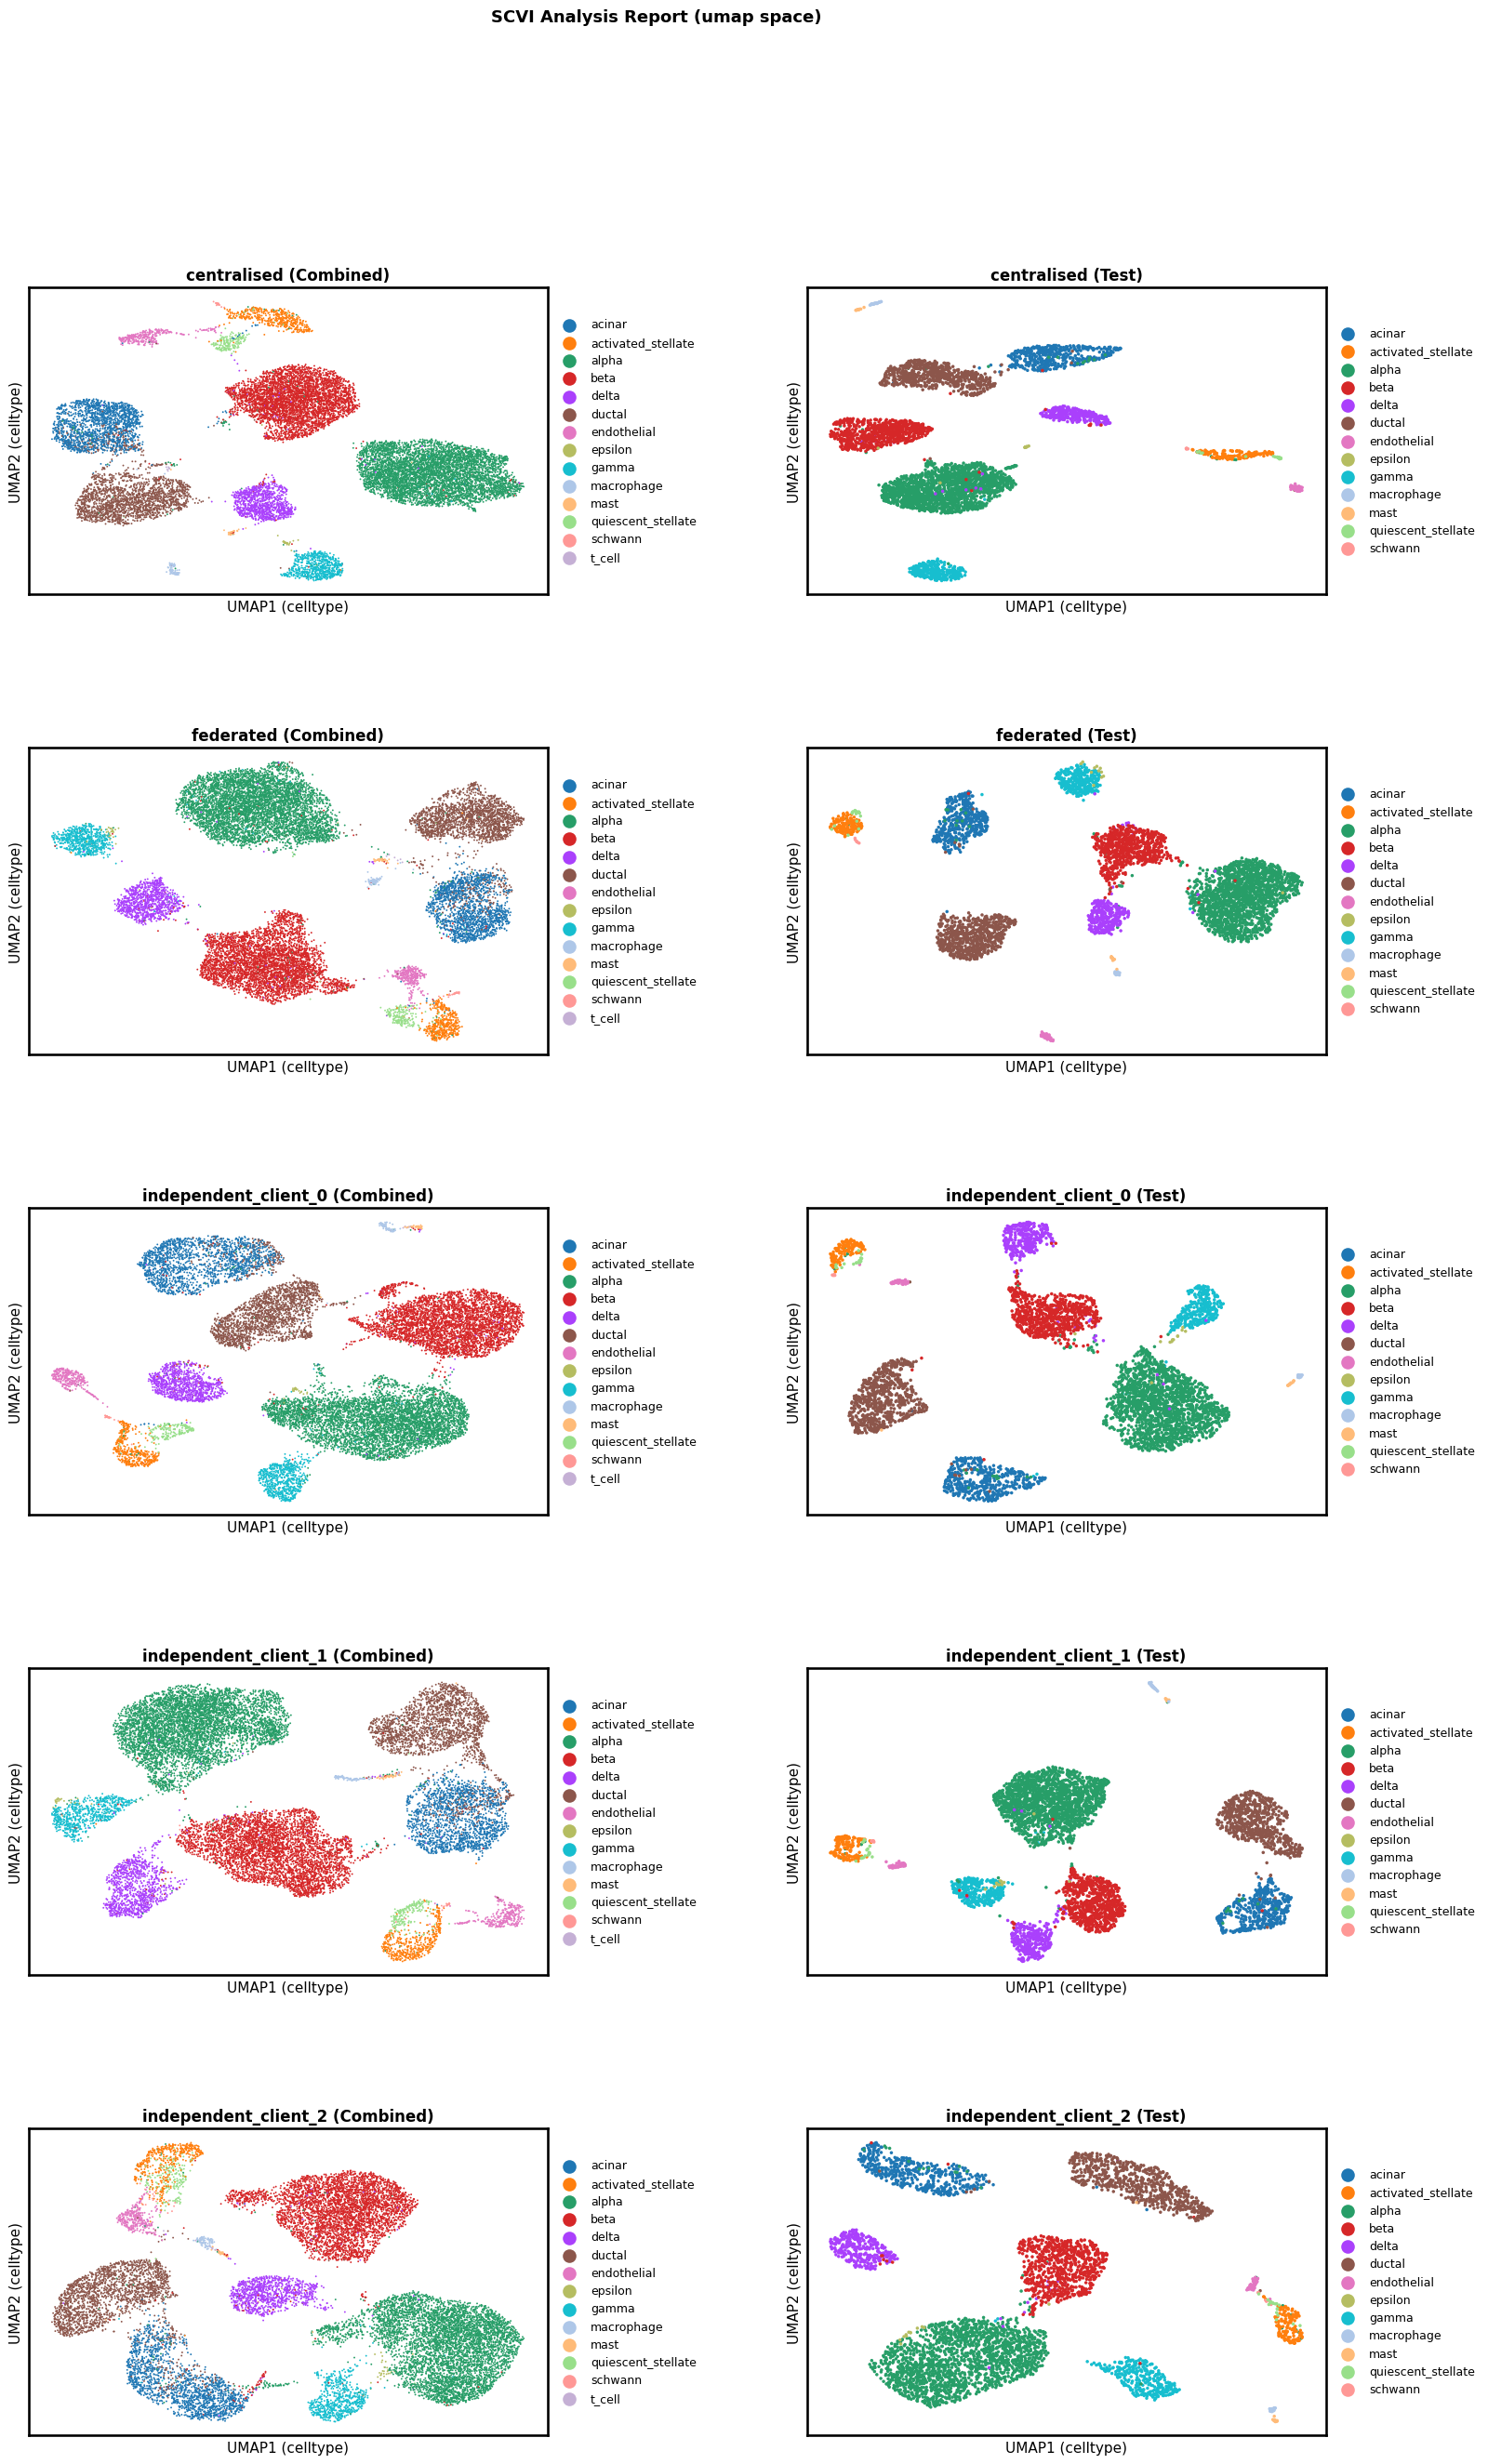

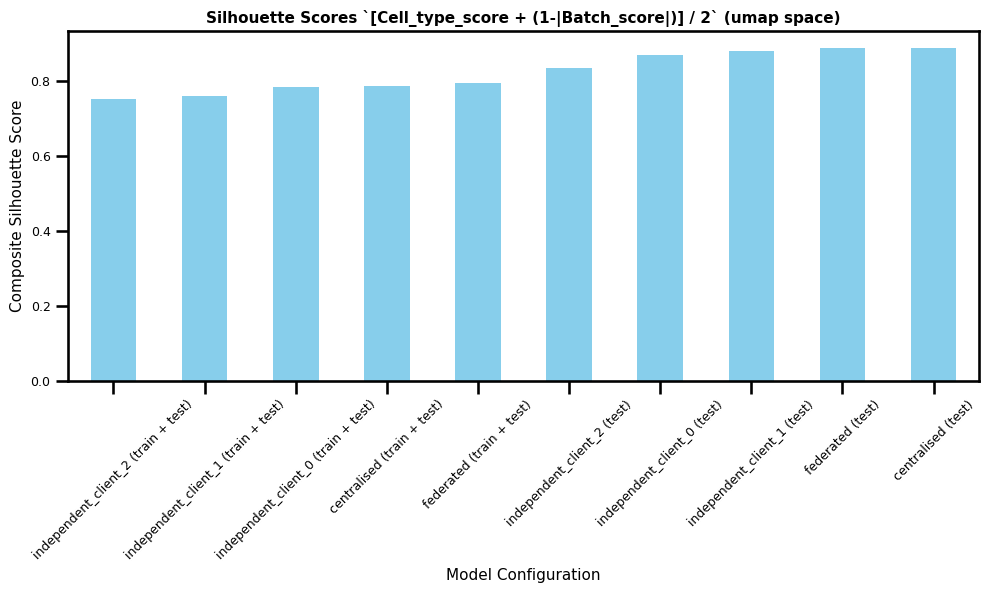

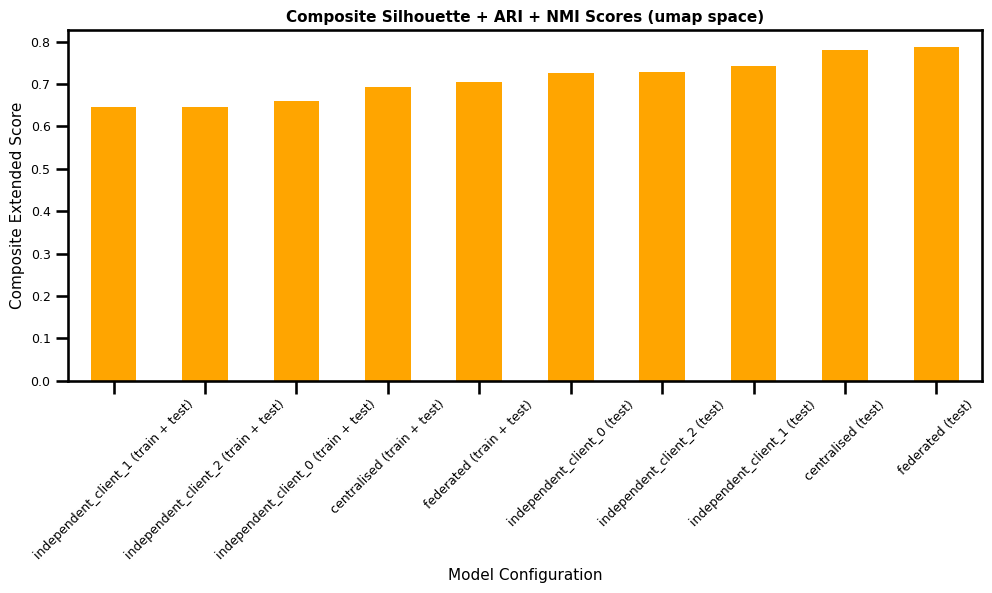



--- Final Summary of All Evaluation Metrics ---


,Entire_dataset_composite_silhouette,Entire_dataset_celltype_silhouette,Entire_dataset_batch_silhouette,Entire_dataset_ari,Entire_dataset_nmi,Entire_dataset_composite_extended,Test_composite_silhouette,Test_celltype_silhouette,Test_batch_silhouette,Test_ari,Test_nmi,Test_composite_extended
centralised,0.786085,0.487925,-0.171793,0.452202,0.746301,0.692668,0.886953,0.577184,0.014687,0.552405,0.799592,0.781476
federated,0.792395,0.462383,-0.146402,0.484592,0.746583,0.703991,0.886736,0.592280,0.022668,0.570657,0.806425,0.787639
independent_client_0,0.783832,0.421427,-0.143049,0.366323,0.711350,0.661334,0.869205,0.515927,0.019553,0.417093,0.747809,0.725828
independent_client_1,0.759305,0.410257,-0.186519,0.361262,0.701341,0.645303,0.877921,0.566254,0.027285,0.446566,0.764172,0.741645
independent_client_2,0.749921,0.345169,-0.172742,0.381438,0.707190,0.647117,0.832325,0.408507,0.039604,0.481680,0.770639,0.729242


In [17]:
print("\n=== Running pipeline in UMAP space ===")
umap_df = run_full_pipeline(space="umap")

### Conclusion and commentary
In both latent and UMAP spaces, the federated model performs similarly to the centralized model on held-out test data, achieving slightly higher ARI/NMI and same composite-extended score (UMAP test: 0.787 vs centralized 0.781), indicating good generalization.
Independent per-client models consistently performs slightly worse compared to both centralized and federated baselines, highlighting the benefit of shared global training. UMAP generally boosts all methods’ metrics over raw latent space. (because latent space is more sparse).
Combined (train+test) evaluations show more negative batch-silhouette and slightly reduced cell-type separation, as expected when merging batches.